# 🧬 Genomic Variant Features — Exploratory Data Analysis

**Dataset:** `variant_features.csv`  
**Kernel:** `bioinfo` (miniconda)  

This notebook performs a thorough EDA on a ClinVar-derived variant feature dataset containing **~117 K variants** annotated with VEP, gnomAD, UniProt structural features, and binary pathogenicity labels.

---
### Table of Contents
1. Environment Setup & Data Load  
2. Dataset Overview  
3. Missing Value Analysis  
4. Label (Pathogenicity) Distribution  
5. Variant-Type & Molecular-Consequence Breakdown  
6. Genomic Location Analysis  
7. Allele-Frequency (gnomAD) Analysis  
8. Protein Position Analysis  
9. VEP Impact & Consequence Analysis  
10. Structural / Functional Feature Analysis  
11. Feature Correlation Analysis  
12. Feature Importance (RandomForest proxy)  
13. Key Takeaways

---
## 1. Environment Setup & Data Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

BG_COLOR     = '#0f1117'
GRID_COLOR   = '#2a2d3e'
TEXT_COLOR   = '#e0e0e0'
ACCENT       = '#7c83fd'
PATH_COLOR   = '#ff6b6b'
BENIGN_COLOR = '#43e97b'
DARK_PALETTE = [BENIGN_COLOR, PATH_COLOR]
PLOTLY_TEMPLATE = 'plotly_dark'

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#0f1117',
    'axes.edgecolor':'#2a2d3e','axes.labelcolor':'#e0e0e0',
    'xtick.color':'#e0e0e0','ytick.color':'#e0e0e0',
    'text.color':'#e0e0e0','grid.color':'#2a2d3e',
    'grid.linestyle':'--','grid.alpha':0.5,
    'font.size':11,'axes.titlesize':14,'axes.titleweight':'bold',
    'legend.facecolor':'#1e2130','legend.edgecolor':'#2a2d3e',
})

print(f'pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

pandas 2.3.3 | numpy 2.2.5 | seaborn 0.13.2


In [2]:
df = pd.read_csv('variant_features.csv', low_memory=False)
# Coerce mixed-type columns to numeric
df['gnomad_found'] = pd.to_numeric(df['gnomad_found'], errors='coerce').fillna(0).astype(int)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.head(3)

Shape: 117,111 rows x 125 columns


Memory: 348.0 MB


,VariationID,label,Gene(s),vep_gene,vep_gene_id,vep_transcript,vep_primary_consequence,vep_impact,vep_biotype,vep_protein_id,...,n_signal_peptide,n_topological_domain,n_disulfide_bond,protein_has_domain,protein_has_active_site,protein_has_binding_site,protein_has_transmembrane,protein_has_signal_peptide,protein_has_disulfide_bond,protein_has_dna_binding
0,1170208,0,SAMD11,SAMD11,ENSG00000187634,ENST00000616016,missense_variant,MODERATE,NaN,ENSP00000478421,...,0,0,0,1,0,0,0,0,0,0
1,789256,0,SAMD11,SAMD11,ENSG00000187634,ENST00000616016,missense_variant,MODERATE,NaN,ENSP00000478421,...,0,0,0,1,0,0,0,0,0,0
2,1140293,0,SAMD11,SAMD11,ENSG00000187634,ENST00000616016,missense_variant,MODERATE,NaN,ENSP00000478421,...,0,0,0,1,0,0,0,0,0,0


---
## 2. Dataset Overview

In [3]:
bool_cols       = [c for c in df.columns if c.startswith('is_') or c.startswith('protein_has_')]
gnomad_cols     = [c for c in df.columns if 'gnomad' in c]
vep_cols        = [c for c in df.columns if c.startswith('vep_')]
structural_cols = [c for c in df.columns if c.startswith('variant_in_') or c.startswith('distance_to_') or c.startswith('n_')]
print(f'Binary (is_/has_): {len(bool_cols)} | gnomAD: {len(gnomad_cols)} | VEP: {len(vep_cols)} | Structural: {len(structural_cols)}')

numeric_df = df.select_dtypes(include=[np.number])
desc = numeric_df.describe().T
desc['cv'] = desc['std'] / desc['mean'].replace(0, np.nan)
desc.sort_values('cv', ascending=False).head(20)

Binary (is_/has_): 24 | gnomAD: 18 | VEP: 20 | Structural: 42


,count,mean,std,min,25%,50%,75%,max,cv
is_inframe_indel,117111.0,0.000009,0.002922,0.0,0.0,0.0,0.0,1.0,342.214845
is_inframe_deletion,117111.0,0.000026,0.005061,0.0,0.0,0.0,0.0,1.0,197.576146
is_genic_upstream,117111.0,0.000102,0.010122,0.0,0.0,0.0,0.0,1.0,98.784277
is_genic_downstream,117111.0,0.000102,0.010122,0.0,0.0,0.0,0.0,1.0,98.784277
vep_strand,117111.0,0.010904,0.999945,-1.0,-1.0,1.0,1.0,1.0,91.702848
is_stop_lost,117111.0,0.000171,0.013067,0.0,0.0,0.0,0.0,1.0,76.515358
is_inframe_insertion,117111.0,0.000256,0.016003,0.0,0.0,0.0,0.0,1.0,62.471860
variant_in_site,117111.0,0.001486,0.038517,0.0,0.0,0.0,0.0,1.0,25.924071
variant_in_active_site,117111.0,0.002126,0.046062,0.0,0.0,0.0,0.0,1.0,21.664010
variant_in_motif,117111.0,0.003586,0.059779,0.0,0.0,0.0,0.0,1.0,16.668476


---
## 3. Missing Value Analysis

Columns with missing: 43/125 | Fully absent: 1


,missing_count,missing_pct
vep_biotype,117111,100.000000
distance_to_nearest_dna_binding,113344,96.783394
distance_to_nearest_zinc_finger,108239,92.424281
distance_to_nearest_coiled_coil,103807,88.639837
distance_to_nearest_active_site,102159,87.232625
distance_to_nearest_site,100162,85.527406
distance_to_nearest_repeat,98016,83.694956
distance_to_nearest_signal_peptide,96023,81.993152
distance_to_nearest_topological_domain,95164,81.259660
distance_to_nearest_disulfide_bond,93155,79.544193


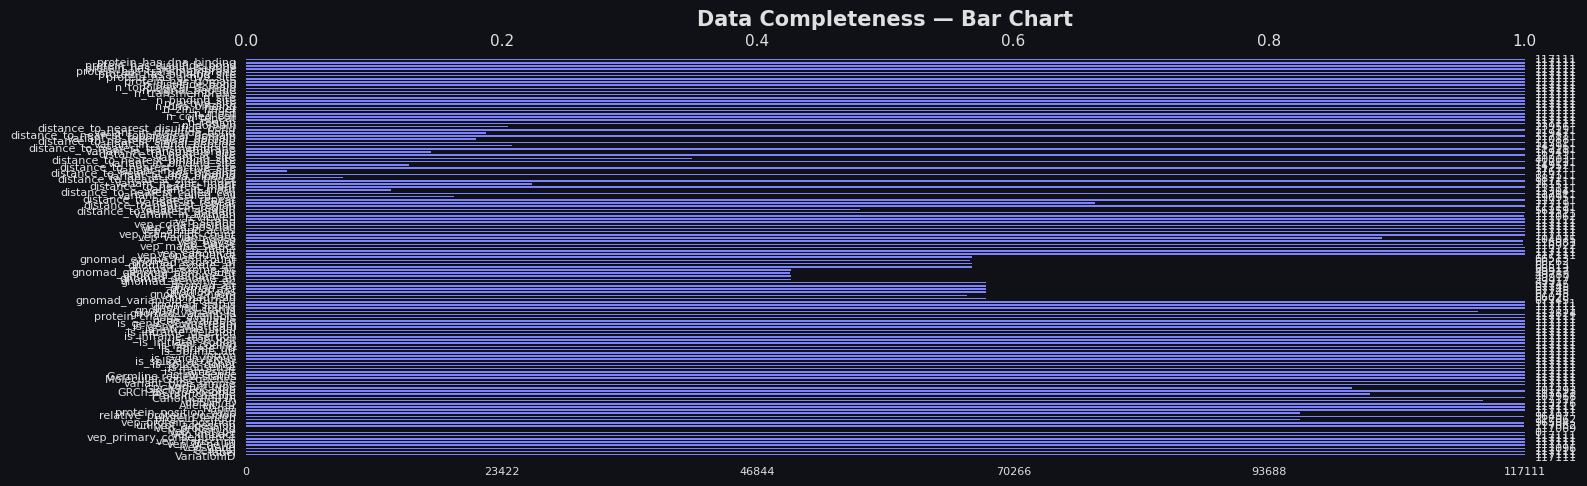

In [4]:
missing = pd.DataFrame({'missing_count':df.isnull().sum(),'missing_pct':df.isnull().mean()*100})
missing = missing.query('missing_count > 0').sort_values('missing_pct', ascending=False)
print(f'Columns with missing: {len(missing)}/{df.shape[1]} | Fully absent: {(missing.missing_pct==100).sum()}')
display(missing.head(30))

fig, ax = plt.subplots(figsize=(16, 5))
msno.bar(df, ax=ax, color=ACCENT, fontsize=8)
ax.set_title('Data Completeness — Bar Chart', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_missing_bar.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

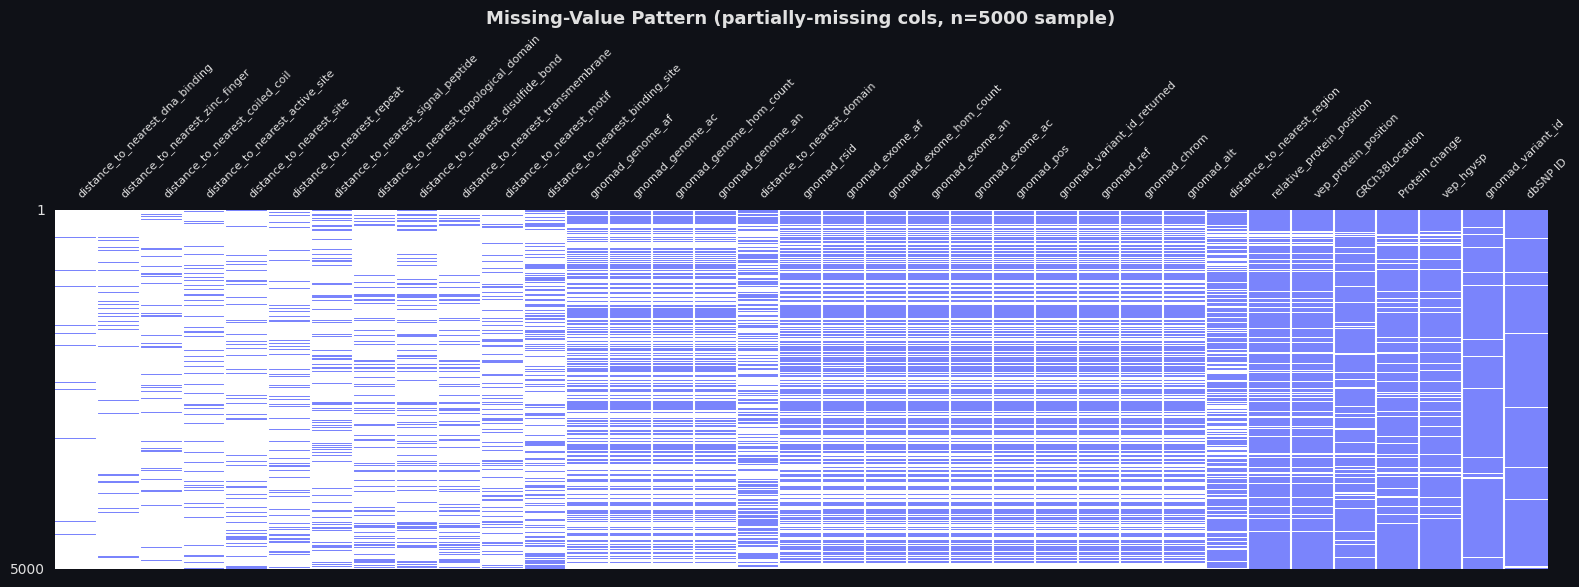

In [5]:
high_missing = missing[missing.missing_pct.between(1, 99)].index.tolist()
fig, ax = plt.subplots(figsize=(16, 6))
msno.matrix(df[high_missing].sample(min(5000, len(df)), random_state=42),
            ax=ax, sparkline=False, fontsize=8, color=(0.48, 0.52, 0.99))
ax.set_title('Missing-Value Pattern (partially-missing cols, n=5000 sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_missing_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 4. Label (Pathogenicity) Distribution

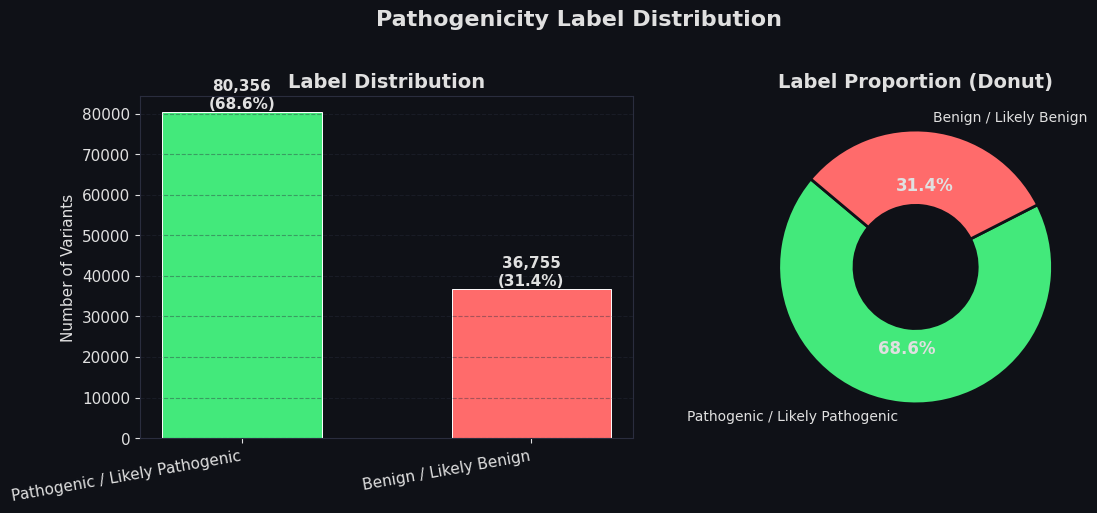

Imbalance ratio: 2.19x


In [6]:
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['label','count']
label_counts['label_name'] = label_counts['label'].map({0:'Benign / Likely Benign', 1:'Pathogenic / Likely Pathogenic'})
label_counts['pct'] = label_counts['count'] / label_counts['count'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
bars = ax.bar(label_counts['label_name'], label_counts['count'],
              color=DARK_PALETTE, edgecolor='white', linewidth=0.7, width=0.55)
for bar, row in zip(bars, label_counts.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{row.count:,}\n({row.pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Label Distribution'); ax.set_ylabel('Number of Variants')
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_counts['label_name'], rotation=10, ha='right')
ax.grid(axis='y', alpha=0.4)

ax = axes[1]
wedges, texts, autotexts = ax.pie(
    label_counts['count'], labels=label_counts['label_name'],
    colors=DARK_PALETTE, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=2),
    textprops={'color':TEXT_COLOR,'fontsize':10})
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(12)
ax.set_title('Label Proportion (Donut)')

fig.suptitle('Pathogenicity Label Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_03_label_dist.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print(f'Imbalance ratio: {label_counts["count"].max()/label_counts["count"].min():.2f}x')

---
## 5. Variant-Type & Molecular-Consequence Breakdown

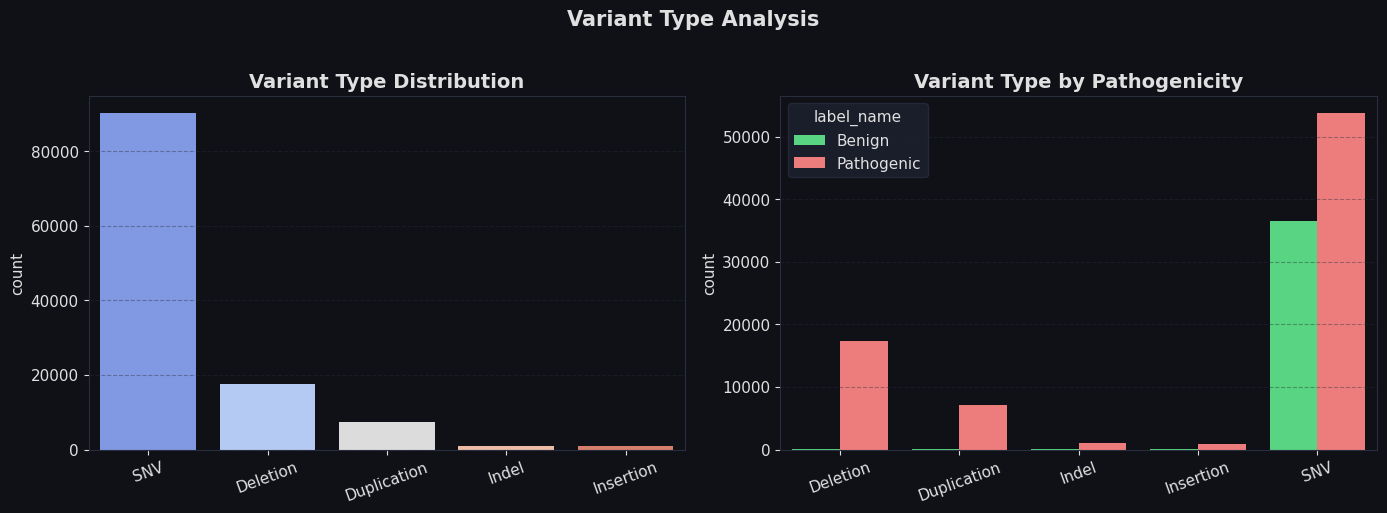

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vt = df['variant_type_simple'].value_counts().reset_index()
vt.columns = ['type','count']
sns.barplot(data=vt, x='type', y='count', palette='coolwarm', ax=axes[0])
axes[0].set_title('Variant Type Distribution'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20); axes[0].grid(axis='y', alpha=0.4)

vt_label = df.groupby(['variant_type_simple','label']).size().reset_index(name='count')
vt_label['label_name'] = vt_label['label'].map({0:'Benign',1:'Pathogenic'})
sns.barplot(data=vt_label, x='variant_type_simple', y='count', hue='label_name',
            palette={'Benign':BENIGN_COLOR,'Pathogenic':PATH_COLOR}, ax=axes[1])
axes[1].set_title('Variant Type by Pathogenicity'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20); axes[1].grid(axis='y', alpha=0.4)

fig.suptitle('Variant Type Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_04_variant_type.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

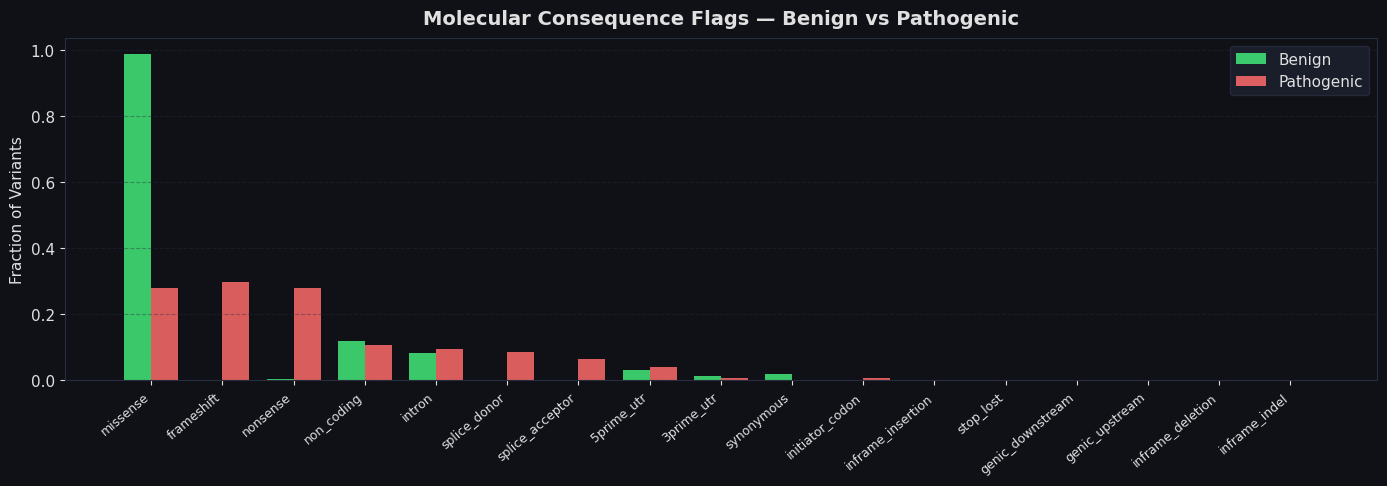

In [8]:
consequence_flags = [c for c in df.columns if c.startswith('is_')]
flag_rates = df[consequence_flags].mean().sort_values(ascending=False)
flag_by_label = pd.DataFrame({'Benign':df[df.label==0][consequence_flags].mean(),
                               'Pathogenic':df[df.label==1][consequence_flags].mean()}).T

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(flag_rates)); w = 0.38
ax.bar(x - w/2, flag_by_label.loc['Benign', flag_rates.index], width=w, label='Benign', color=BENIGN_COLOR, alpha=0.85)
ax.bar(x + w/2, flag_by_label.loc['Pathogenic', flag_rates.index], width=w, label='Pathogenic', color=PATH_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('is_','') for c in flag_rates.index], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Fraction of Variants')
ax.set_title('Molecular Consequence Flags — Benign vs Pathogenic', pad=10)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_05_consequence_flags.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 6. Genomic Location Analysis

In [9]:
chrom_order = [str(i) for i in range(1,23)] + ['X','Y','MT']
chrom_col = 'GRCh38Chromosome'
chrom_counts = df.groupby([chrom_col,'label']).size().reset_index(name='count')
chrom_counts[chrom_col] = chrom_counts[chrom_col].astype(str)
chrom_counts = chrom_counts[chrom_counts[chrom_col].isin(chrom_order)]
chrom_counts[chrom_col] = pd.Categorical(chrom_counts[chrom_col], categories=chrom_order, ordered=True)
chrom_counts = chrom_counts.sort_values(chrom_col)
chrom_counts['label_name'] = chrom_counts['label'].map({0:'Benign',1:'Pathogenic'})

fig = px.bar(chrom_counts, x=chrom_col, y='count', color='label_name',
             color_discrete_map={'Benign':BENIGN_COLOR,'Pathogenic':PATH_COLOR},
             barmode='stack', template=PLOTLY_TEMPLATE,
             title='Variant Count per Chromosome',
             labels={chrom_col:'Chromosome','count':'Variant Count','label_name':'Label'})
fig.update_layout(plot_bgcolor=BG_COLOR, paper_bgcolor=BG_COLOR, font_color=TEXT_COLOR)
fig.show()

---
## 7. Allele-Frequency (gnomAD) Analysis

gnomAD presence by label:


,gnomad_found_rate
label,
Benign,0.984084
Pathogenic,0.362624


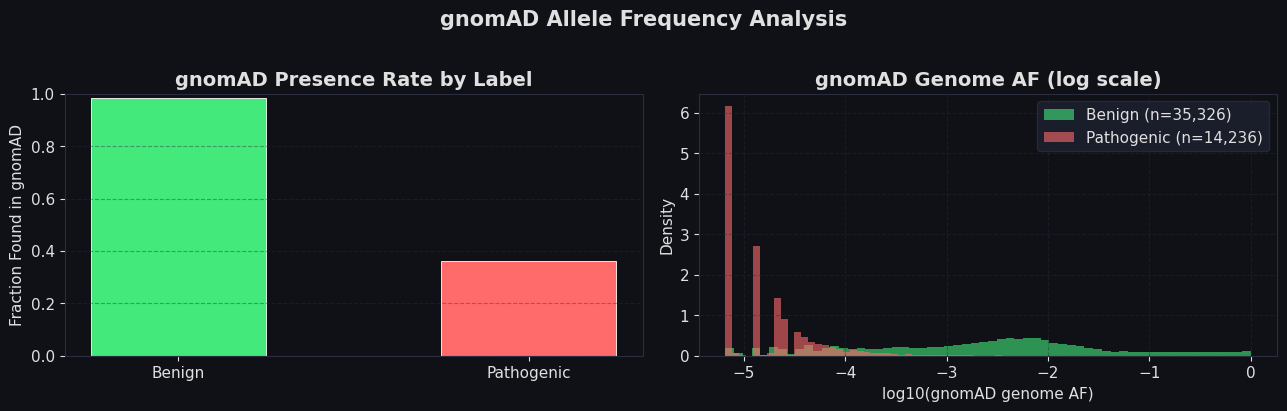

In [10]:
print('gnomAD presence by label:')
gf = df.groupby('label')['gnomad_found'].mean().rename(index={0:'Benign',1:'Pathogenic'})
display(gf.to_frame('gnomad_found_rate'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

found_by_label = df.groupby('label')['gnomad_found'].mean().reset_index()
found_by_label['label_name'] = found_by_label['label'].map({0:'Benign',1:'Pathogenic'})
axes[0].bar(found_by_label['label_name'], found_by_label['gnomad_found'],
            color=DARK_PALETTE, width=0.5, edgecolor='white', linewidth=0.6)
axes[0].set_ylabel('Fraction Found in gnomAD'); axes[0].set_title('gnomAD Presence Rate by Label')
axes[0].set_ylim(0,1); axes[0].grid(axis='y', alpha=0.4)

for lbl, color, name in [(0,BENIGN_COLOR,'Benign'),(1,PATH_COLOR,'Pathogenic')]:
    af = df[(df.label==lbl)&(df.gnomad_genome_af>0)]['gnomad_genome_af']
    axes[1].hist(np.log10(af+1e-10), bins=60, alpha=0.6, color=color, label=f'{name} (n={len(af):,})', density=True)
axes[1].set_xlabel('log10(gnomAD genome AF)'); axes[1].set_ylabel('Density')
axes[1].set_title('gnomAD Genome AF (log scale)'); axes[1].legend(); axes[1].grid(alpha=0.4)

fig.suptitle('gnomAD Allele Frequency Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_06_gnomad_af.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [11]:
df_af = df[(df.gnomad_genome_af>0)&(df.gnomad_exome_af>0)].copy()
df_af['log_genome_af'] = np.log10(df_af['gnomad_genome_af']+1e-10)
df_af['log_exome_af']  = np.log10(df_af['gnomad_exome_af']+1e-10)
df_af['label_name']    = df_af['label'].map({0:'Benign',1:'Pathogenic'})

fig = px.scatter(df_af.sample(min(8000,len(df_af)),random_state=0),
    x='log_genome_af', y='log_exome_af', color='label_name',
    color_discrete_map={'Benign':BENIGN_COLOR,'Pathogenic':PATH_COLOR},
    opacity=0.4, template=PLOTLY_TEMPLATE,
    labels={'log_genome_af':'log10(Genome AF)','log_exome_af':'log10(Exome AF)','label_name':'Label'},
    title='gnomAD Genome vs Exome AF (log scale, n=8k sample)')
fig.add_shape(type='line', x0=-10, y0=-10, x1=0, y1=0, line=dict(dash='dash',color='gray',width=1))
fig.update_layout(plot_bgcolor=BG_COLOR, paper_bgcolor=BG_COLOR, font_color=TEXT_COLOR)
fig.show()

---
## 8. Protein Position Analysis

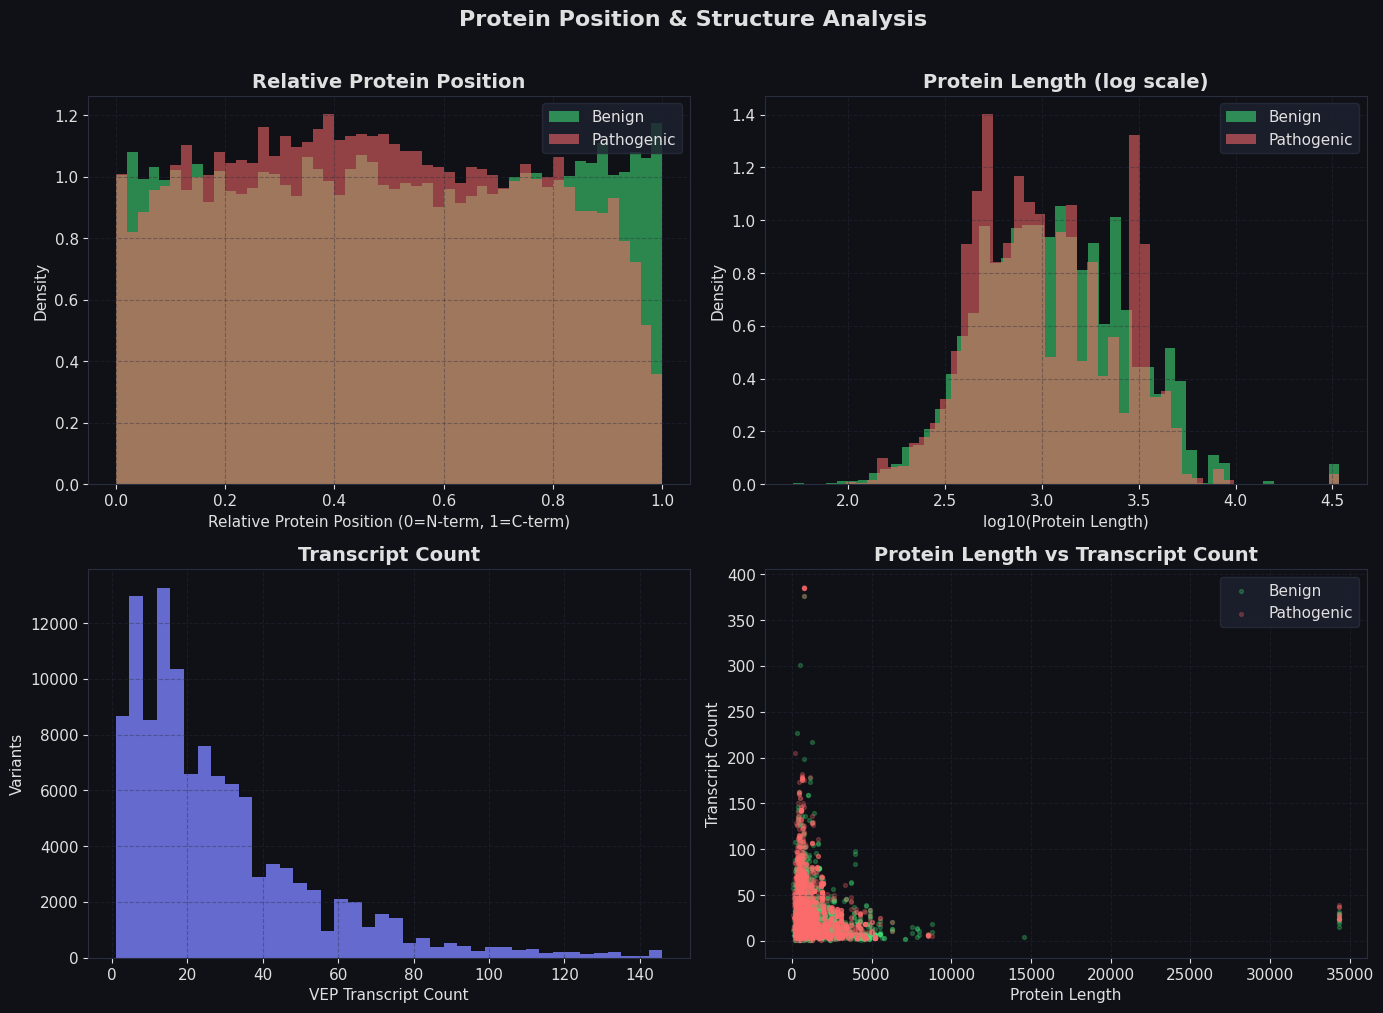

In [12]:
pos_df = df[df['protein_position_valid']==1].copy()
pos_df['label_name'] = pos_df['label'].map({0:'Benign',1:'Pathogenic'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for lbl,color,name in [(0,BENIGN_COLOR,'Benign'),(1,PATH_COLOR,'Pathogenic')]:
    subset = pos_df[pos_df.label==lbl]['relative_protein_position'].dropna()
    axes[0,0].hist(subset, bins=50, alpha=0.55, color=color, density=True, label=name)
axes[0,0].set_xlabel('Relative Protein Position (0=N-term, 1=C-term)')
axes[0,0].set_ylabel('Density'); axes[0,0].set_title('Relative Protein Position')
axes[0,0].legend(); axes[0,0].grid(alpha=0.4)

for lbl,color,name in [(0,BENIGN_COLOR,'Benign'),(1,PATH_COLOR,'Pathogenic')]:
    subset = pos_df[pos_df.label==lbl]['protein_length'].dropna()
    axes[0,1].hist(np.log10(subset+1), bins=50, alpha=0.55, color=color, density=True, label=name)
axes[0,1].set_xlabel('log10(Protein Length)'); axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Protein Length (log scale)'); axes[0,1].legend(); axes[0,1].grid(alpha=0.4)

tc = df['vep_transcript_count'].dropna()
axes[1,0].hist(tc[tc<tc.quantile(0.99)], bins=40, color=ACCENT, alpha=0.8)
axes[1,0].set_xlabel('VEP Transcript Count'); axes[1,0].set_ylabel('Variants')
axes[1,0].set_title('Transcript Count'); axes[1,0].grid(alpha=0.4)

sample = pos_df.sample(min(5000,len(pos_df)), random_state=42)
for lbl,color,name in [(0,BENIGN_COLOR,'Benign'),(1,PATH_COLOR,'Pathogenic')]:
    s = sample[sample.label==lbl]
    axes[1,1].scatter(s['protein_length'], s['vep_transcript_count'], c=color, alpha=0.25, s=8, label=name)
axes[1,1].set_xlabel('Protein Length'); axes[1,1].set_ylabel('Transcript Count')
axes[1,1].set_title('Protein Length vs Transcript Count'); axes[1,1].legend(); axes[1,1].grid(alpha=0.4)

fig.suptitle('Protein Position & Structure Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_07_protein_position.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 9. VEP Impact & Consequence Analysis

In [13]:
impact_counts = df.groupby(['vep_impact','label']).size().reset_index(name='count')
impact_counts['label_name'] = impact_counts['label'].map({0:'Benign',1:'Pathogenic'})

fig = px.bar(impact_counts, x='vep_impact', y='count', color='label_name',
    color_discrete_map={'Benign':BENIGN_COLOR,'Pathogenic':PATH_COLOR},
    barmode='group', template=PLOTLY_TEMPLATE,
    category_orders={'vep_impact':['LOW','MODIFIER','MODERATE','HIGH']},
    title='VEP Impact Category by Pathogenicity',
    labels={'vep_impact':'VEP Impact','count':'Count','label_name':'Label'})
fig.update_layout(plot_bgcolor=BG_COLOR, paper_bgcolor=BG_COLOR, font_color=TEXT_COLOR)
fig.show()

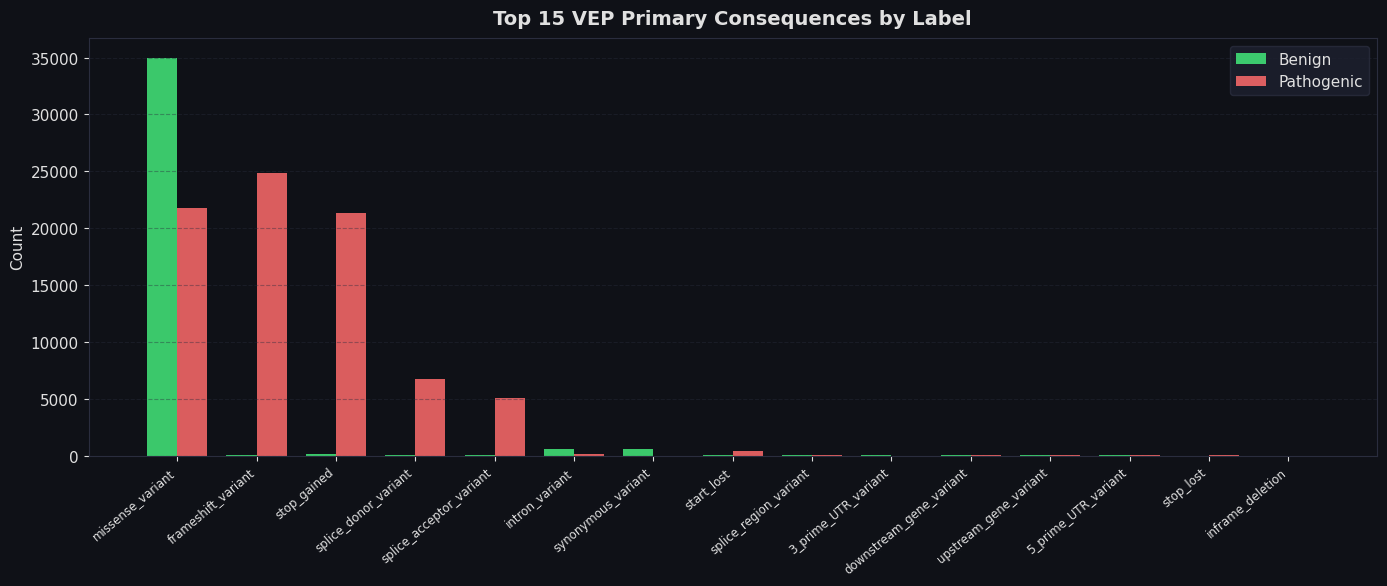

In [14]:
top_consq = df['vep_primary_consequence'].value_counts().head(15).index
consq_df  = df[df['vep_primary_consequence'].isin(top_consq)]
consq_df  = consq_df.groupby(['vep_primary_consequence','label']).size().reset_index(name='count')
consq_df['label_name'] = consq_df['label'].map({0:'Benign',1:'Pathogenic'})

fig, ax = plt.subplots(figsize=(14, 6))
pivot = consq_df.pivot(index='vep_primary_consequence', columns='label_name', values='count').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
x = np.arange(len(pivot)); w = 0.38
ax.bar(x-w/2, pivot.get('Benign',0),     width=w, label='Benign',     color=BENIGN_COLOR, alpha=0.85)
ax.bar(x+w/2, pivot.get('Pathogenic',0), width=w, label='Pathogenic', color=PATH_COLOR,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('Count'); ax.set_title('Top 15 VEP Primary Consequences by Label', pad=10)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_08_vep_consequence.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 10. Structural / Functional Feature Analysis

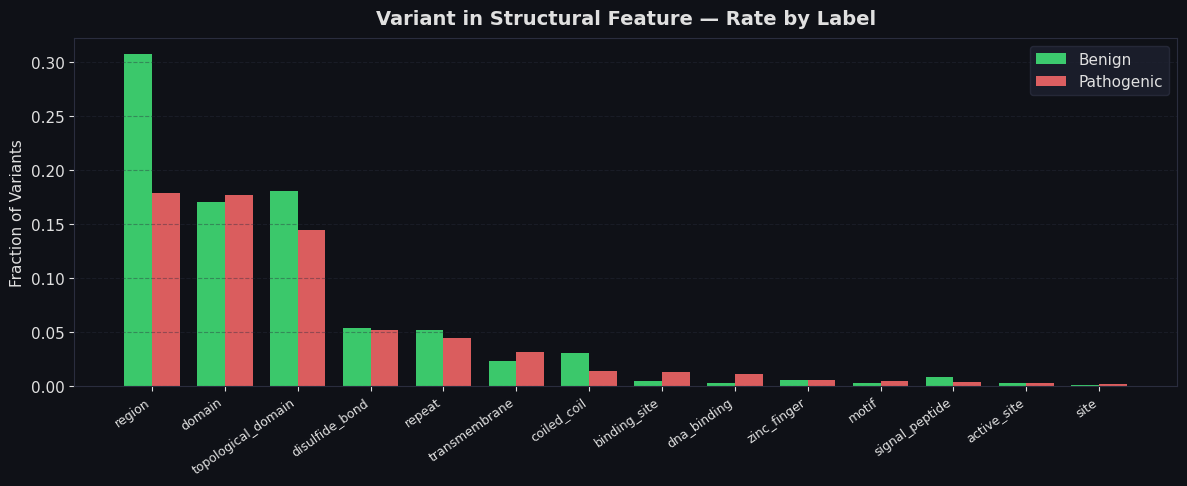

In [15]:
struct_flags = [c for c in df.columns if c.startswith('variant_in_')]
struct_rates = pd.DataFrame({
    'Feature'   : [c.replace('variant_in_','') for c in struct_flags],
    'Benign'    : [df[df.label==0][c].mean() for c in struct_flags],
    'Pathogenic': [df[df.label==1][c].mean() for c in struct_flags],
}).sort_values('Pathogenic', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(struct_rates)); w = 0.38
ax.bar(x-w/2, struct_rates['Benign'],     width=w, label='Benign',     color=BENIGN_COLOR, alpha=0.85)
ax.bar(x+w/2, struct_rates['Pathogenic'], width=w, label='Pathogenic', color=PATH_COLOR,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(struct_rates['Feature'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Fraction of Variants'); ax.set_title('Variant in Structural Feature — Rate by Label', pad=10)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_09_structural_features.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

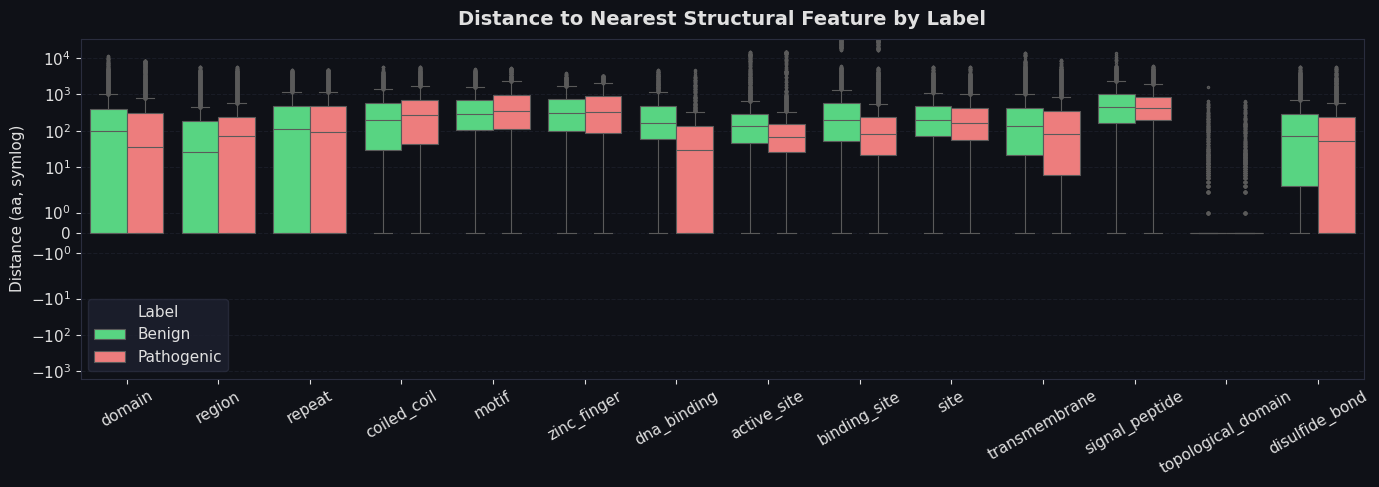

In [16]:
dist_cols = [c for c in df.columns if c.startswith('distance_to_nearest_')]
dist_long = []
for col in dist_cols:
    s = df[[col,'label']].dropna().rename(columns={col:'distance'})
    s['feature'] = col.replace('distance_to_nearest_','')
    dist_long.append(s)
dist_long = pd.concat(dist_long, ignore_index=True)
dist_long['label_name'] = dist_long['label'].map({0:'Benign',1:'Pathogenic'})

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=dist_long, x='feature', y='distance', hue='label_name',
            palette={'Benign':BENIGN_COLOR,'Pathogenic':PATH_COLOR},
            fliersize=1.5, linewidth=0.8, ax=ax)
ax.set_yscale('symlog'); ax.set_xlabel(''); ax.set_ylabel('Distance (aa, symlog)')
ax.set_title('Distance to Nearest Structural Feature by Label', pad=10)
ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.4); ax.legend(title='Label')
plt.tight_layout()
plt.savefig('plot_10_distance_features.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 11. Feature Correlation Analysis

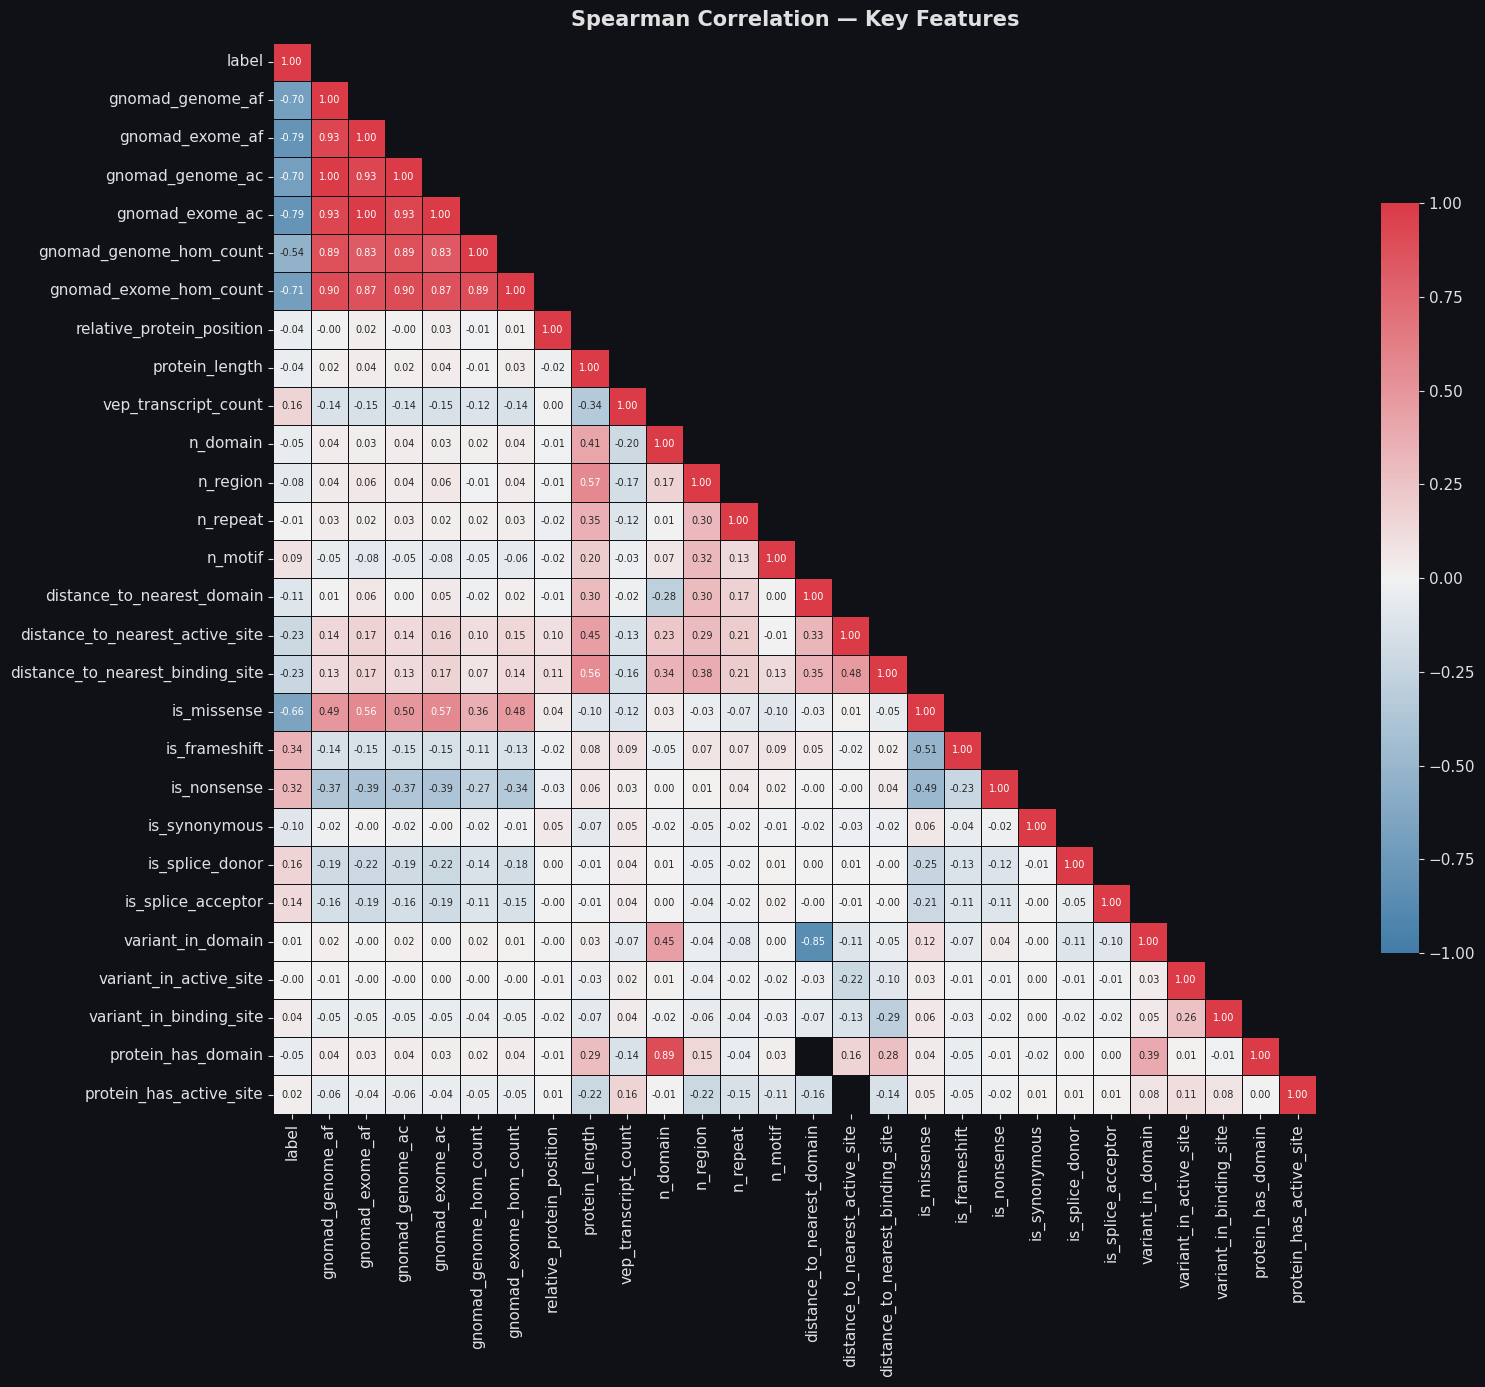

In [17]:
corr_cols = ['label','gnomad_genome_af','gnomad_exome_af','gnomad_genome_ac','gnomad_exome_ac',
             'gnomad_genome_hom_count','gnomad_exome_hom_count','relative_protein_position',
             'protein_length','vep_transcript_count','n_domain','n_region','n_repeat','n_motif',
             'distance_to_nearest_domain','distance_to_nearest_active_site','distance_to_nearest_binding_site',
             'is_missense','is_frameshift','is_nonsense','is_synonymous','is_splice_donor','is_splice_acceptor',
             'variant_in_domain','variant_in_active_site','variant_in_binding_site',
             'protein_has_domain','protein_has_active_site']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, linecolor=BG_COLOR, cbar_kws={'shrink':0.7}, ax=ax)
ax.set_title('Spearman Correlation — Key Features', fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_11_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

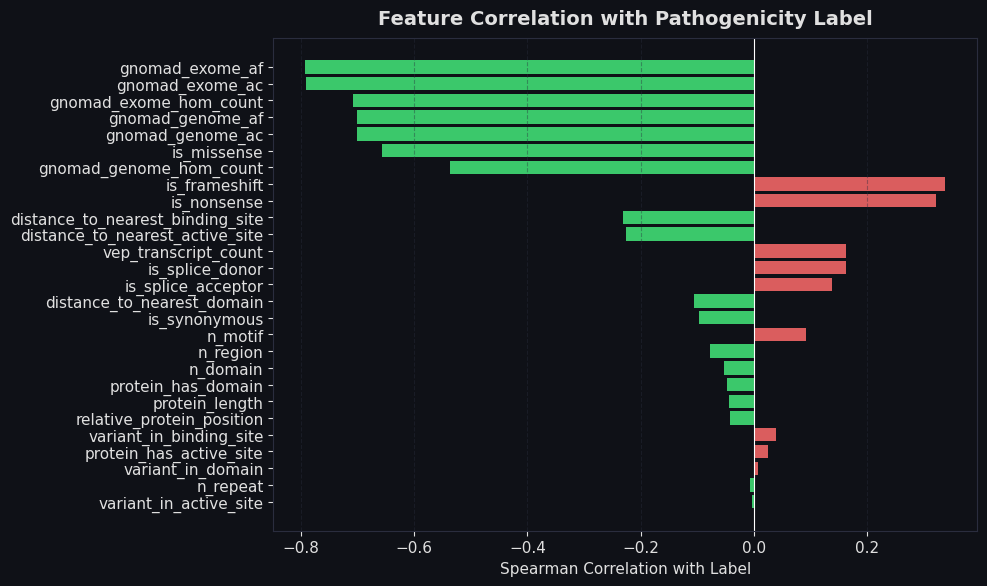

In [18]:
label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PATH_COLOR if v>0 else BENIGN_COLOR for v in label_corr.values]
ax.barh(label_corr.index[::-1], label_corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Spearman Correlation with Label')
ax.set_title('Feature Correlation with Pathogenicity Label', pad=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_12_label_corr.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 12. Feature Importance (RandomForest Proxy)

In [19]:
rf_cols = ['gnomad_genome_af','gnomad_exome_af','gnomad_genome_hom_count','gnomad_exome_hom_count',
           'gnomad_found','gnomad_genome_ac','gnomad_exome_ac','relative_protein_position',
           'protein_length','vep_transcript_count','n_domain','n_region','n_repeat','n_motif',
           'n_active_site','n_binding_site','n_transmembrane','n_disulfide_bond',
           'distance_to_nearest_domain','distance_to_nearest_region','distance_to_nearest_active_site',
           'distance_to_nearest_binding_site','distance_to_nearest_transmembrane','distance_to_nearest_disulfide_bond',
           'variant_in_domain','variant_in_active_site','variant_in_binding_site',
           'variant_in_transmembrane','variant_in_disulfide_bond',
           'protein_has_domain','protein_has_active_site','protein_has_binding_site',
           'protein_has_transmembrane','protein_has_disulfide_bond',
           'is_missense','is_frameshift','is_nonsense','is_synonymous',
           'is_splice_donor','is_splice_acceptor','is_intron','is_5prime_utr','is_3prime_utr',
           'is_inframe_insertion','is_inframe_deletion','gene_available','protein_change_available']
rf_cols = [c for c in rf_cols if c in df.columns]

rf_df = df[rf_cols+['label']].dropna()
X = rf_df[rf_cols].values; y = rf_df['label'].values
if len(rf_df)>40000:
    idx = np.random.RandomState(42).choice(len(rf_df), 40000, replace=False)
    X, y = X[idx], y[idx]

print(f'Training RandomForest on {len(y):,} samples, {len(rf_cols)} features...')
rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, class_weight='balanced', random_state=42)
rf.fit(X, y)
print('Done.')

Training RandomForest on 506 samples, 47 features...


Done.


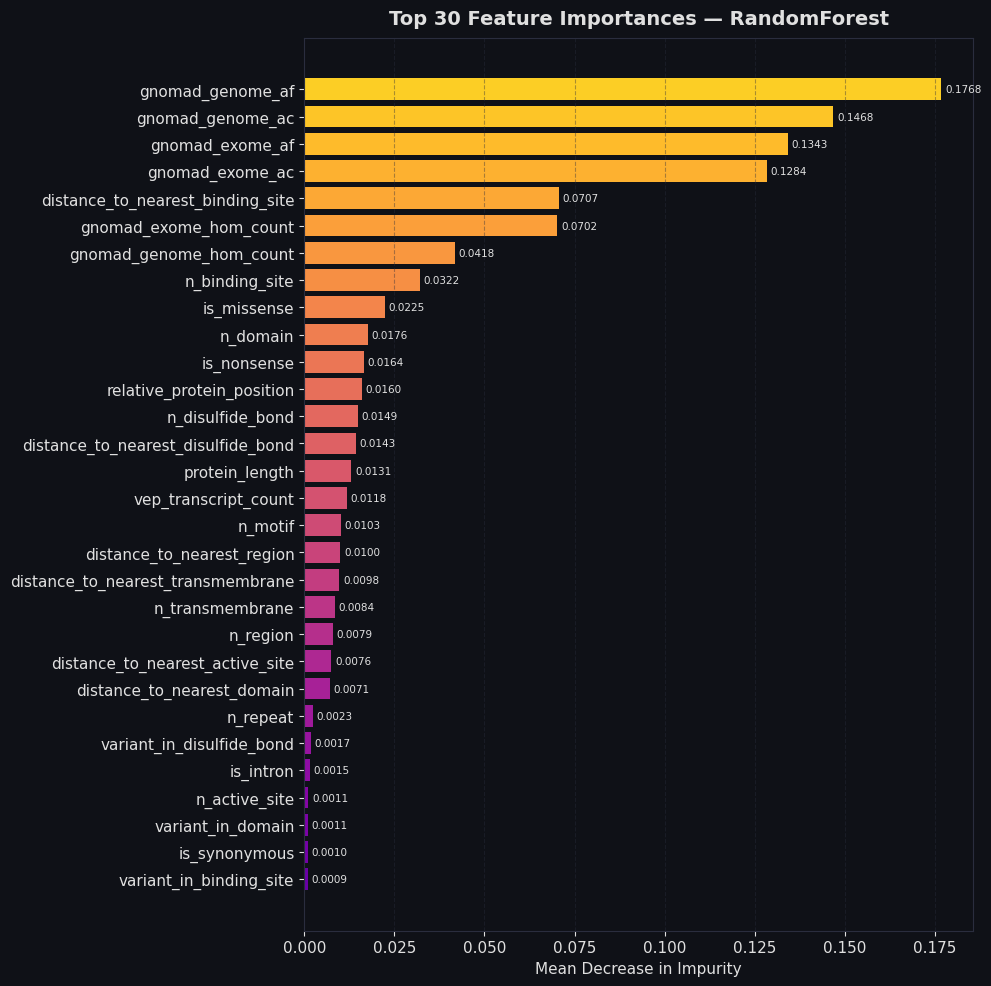

In [20]:
importances = pd.Series(rf.feature_importances_, index=rf_cols).sort_values(ascending=True)
TOP_N = 30
top_imp = importances.tail(TOP_N)

fig, ax = plt.subplots(figsize=(10, 10))
colors_imp = plt.cm.plasma(np.linspace(0.2, 0.9, TOP_N))
bars = ax.barh(top_imp.index, top_imp.values, color=colors_imp, edgecolor='none')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(f'Top {TOP_N} Feature Importances — RandomForest', pad=10)
ax.grid(axis='x', alpha=0.4)
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('plot_13_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---
## 13. Key Takeaways

In [21]:
n_benign = (df.label==0).sum(); n_path = (df.label==1).sum()
top3_feat = importances.tail(3).index.tolist()[::-1]

summary = pd.DataFrame([
    ['Total variants',            f'{len(df):,}'],
    ['Feature columns',           str(df.shape[1])],
    ['Benign variants',           f'{n_benign:,} ({n_benign/len(df)*100:.1f}%)'],
    ['Pathogenic variants',       f'{n_path:,} ({n_path/len(df)*100:.1f}%)'],
    ['Class imbalance ratio',     f'{max(n_benign,n_path)/min(n_benign,n_path):.2f}x'],
    ['Columns with any missing',  str(df.isnull().any().sum())],
    ['gnomAD presence — Benign',  f'{df[df.label==0].gnomad_found.mean()*100:.1f}%'],
    ['gnomAD presence — Path.',   f'{df[df.label==1].gnomad_found.mean()*100:.1f}%'],
    ['Dominant variant type',     df.variant_type_simple.mode()[0]],
    ['Most common VEP impact',    df.vep_impact.mode()[0]],
    ['Top RF feature #1',         top3_feat[0]],
    ['Top RF feature #2',         top3_feat[1]],
    ['Top RF feature #3',         top3_feat[2]],
], columns=['Metric','Value'])

display(summary.style
    .set_properties(**{'background-color':'#1e2130','color':'#e0e0e0','border':'1px solid #2a2d3e'})
    .set_table_styles([{'selector':'th','props':[('background-color','#2a2d3e'),('color','#7c83fd'),('font-weight','bold')]}])
)

,Metric,Value
0,Total variants,"117,111"
1,Feature columns,125
2,Benign variants,"36,755 (31.4%)"
3,Pathogenic variants,"80,356 (68.6%)"
4,Class imbalance ratio,2.19x
5,Columns with any missing,43
6,gnomAD presence — Benign,98.4%
7,gnomAD presence — Path.,36.3%
8,Dominant variant type,SNV
9,Most common VEP impact,HIGH


### Key Findings

| # | Observation |
|---|-------------|
| 1 | **Class imbalance** is present; downstream ML should use balanced weights or resampling. |
| 2 | **gnomAD presence** is strongly enriched in benign variants — rare/absent variants are more often pathogenic. |
| 3 | **Allele frequency** (gnomAD genome/exome AF) shows clear bimodal separation by label. |
| 4 | **Frameshift & nonsense variants** are strongly enriched in pathogenics; synonymous variants dominate the benign class. |
| 5 | **Structural proximity** — variants overlapping active sites, binding sites, and domains show higher pathogenic rates. |
| 6 | **Missing data** is concentrated in structural annotation and gnomAD allele-count fields, not in core label/type columns. |
| 7 | **Protein length** differs: pathogenic variants tend to occur in larger proteins with more annotated features. |

> Dataset is well-suited for supervised binary classification. Priority features: gnomAD AF, variant consequence type, structural context, and protein position.